In [1]:
import torch
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import StandardScaler
import h5py

In [2]:
import logging

logging.basicConfig(
    format='[%(asctime)s] %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    level=logging.DEBUG
)

logger = logging.getLogger()
logger.info("hi")  # Same clean output

[2025-12-09 19:34:00] hi


In [4]:
# Constants
METADATA_PATH = "/home/harinit9/orcd/pool/musicgen-data-nokey/tempo_metadata.json"
ACTS_BY_LAYER_PATH = Path("/home/wyf/orcd/pool/musicgen-activations-nokey/acts_by_layer")

In [5]:
with open(METADATA_PATH) as fin:
    metadata = json.load(fin)

In [149]:
# Define main fitting function based on layer idx
def train_linear_probe(
    layer_idx: int,
    pca_dim: int,
    pooling_strat: str,
    n_tests: int = 1024,
):
    acts = np.load(ACTS_BY_LAYER_PATH / f"layer_{layer_idx:02d}.npy")
    logger.info(f"Logistic regression on {layer_idx=}")

    # Pool across time
    logger.info("Pooling...")
    if pooling_strat == "max":
        X_pooled = np.max(acts, axis=1)
    else:
        X_pooled = np.mean(acts, axis=1)

    # Normalize per feature
    logger.info("Normalizing...")
    # X_norm = StandardScaler().fit_transform(X_pooled)

    # Run PCA to reduce dimensionality
    from sklearn.decomposition import PCA

    logger.info("Running pca...")
    pca = PCA(n_components=pca_dim)
    X_pca = pca.fit_transform(X_pooled)     # shape: (1000, pca_dim)
    y_raw = np.array([clip["tempo_bpm"] for clip in metadata])

    # y_raw = np.random.rand(*y_raw.shape) * 100 + 50
    y_raw = np.random.randn(*y_raw.shape) * np.std(y_raw) + np.mean(y_raw)

    # Make train/test splits
    logger.info("Making test splits...")

    for _ in range(n_tests):
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(
            X_pca, y_raw,
            test_size=0.3,
        )

        # Run logistic regression
        from sklearn.linear_model import LogisticRegression, LinearRegression

        # logger.info("Fitting logistic regression...")
        reg = LinearRegression()
        reg.fit(X_train, y_train)

        def evaluate(X, y):
            y_pred = reg.predict(X)

            mse = np.mean((y_pred - y)**2)
            return mse
        
        # logger.info("Running eval...")
        train_acc = evaluate(X_train, y_train)
        test_acc = evaluate(X_test, y_test)

        print(f"[{layer_idx=}]  train_mse={train_acc:.3f}, test_mse={test_acc:.3f}")
        yield train_acc, test_acc

(array([  3.,  15.,  41., 123., 215., 232., 202., 118.,  38.,  13.]),
 array([-60.20289894, -28.79835833,   2.60618229,  34.0107229 ,
         65.41526351,  96.81980412, 128.22434474, 159.62888535,
        191.03342596, 222.43796657, 253.84250719]),
 <BarContainer object of 10 artists>)

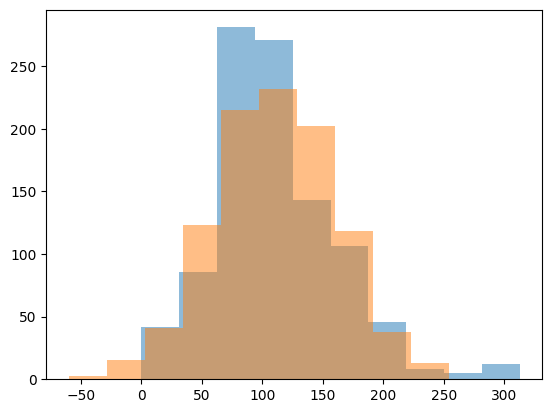

In [150]:
y_raw = np.array([ clip["tempo_bpm"] for clip in metadata ])
y_raw_rand = np.random.randn(*y_raw.shape) * np.std(y_raw) + np.mean(y_raw)
plt.hist(y_raw, alpha=0.5)
plt.hist(y_raw_rand, alpha=0.5)

In [151]:
records = []

In [152]:
# logger.setLevel("ERROR")
logger.setLevel("DEBUG")

# Runs in 2m
for layer_idx in [0, 12, 24, 36, 47]:
    accs = list(train_linear_probe(layer_idx, 128, "max", n_tests=128))
    records.append((layer_idx, accs))

[2025-12-09 20:35:59] Logistic regression on layer_idx=0
[2025-12-09 20:35:59] Pooling...
[2025-12-09 20:35:59] Normalizing...
[2025-12-09 20:35:59] Running pca...
[2025-12-09 20:36:00] Making test splits...


[layer_idx=0]  train_mse=1838.456, test_mse=3047.288
[layer_idx=0]  train_mse=2061.089, test_mse=2271.599
[layer_idx=0]  train_mse=1927.391, test_mse=2730.620
[layer_idx=0]  train_mse=1923.217, test_mse=2781.753
[layer_idx=0]  train_mse=1934.829, test_mse=2780.385
[layer_idx=0]  train_mse=1946.041, test_mse=2743.178
[layer_idx=0]  train_mse=1863.469, test_mse=3072.322
[layer_idx=0]  train_mse=1978.530, test_mse=2662.992
[layer_idx=0]  train_mse=1827.892, test_mse=3068.896
[layer_idx=0]  train_mse=1917.822, test_mse=2848.861
[layer_idx=0]  train_mse=1858.623, test_mse=3078.573
[layer_idx=0]  train_mse=1847.106, test_mse=3001.403
[layer_idx=0]  train_mse=1981.593, test_mse=2615.846
[layer_idx=0]  train_mse=1890.027, test_mse=2783.402
[layer_idx=0]  train_mse=1889.480, test_mse=2782.831
[layer_idx=0]  train_mse=1972.570, test_mse=2676.404
[layer_idx=0]  train_mse=1963.394, test_mse=2699.325
[layer_idx=0]  train_mse=1847.430, test_mse=2998.277
[layer_idx=0]  train_mse=1982.512, test_mse=26

[2025-12-09 20:36:27] Logistic regression on layer_idx=12
[2025-12-09 20:36:27] Pooling...
[2025-12-09 20:36:27] Normalizing...
[2025-12-09 20:36:27] Running pca...
[2025-12-09 20:36:27] Making test splits...


[layer_idx=12]  train_mse=1838.226, test_mse=2778.416
[layer_idx=12]  train_mse=1908.270, test_mse=2710.193
[layer_idx=12]  train_mse=1832.971, test_mse=2981.815
[layer_idx=12]  train_mse=1801.523, test_mse=2850.490
[layer_idx=12]  train_mse=1862.477, test_mse=2712.201
[layer_idx=12]  train_mse=1906.671, test_mse=2636.317
[layer_idx=12]  train_mse=1890.920, test_mse=2797.829
[layer_idx=12]  train_mse=1843.053, test_mse=2734.004
[layer_idx=12]  train_mse=1948.157, test_mse=2563.114
[layer_idx=12]  train_mse=1818.853, test_mse=2888.373
[layer_idx=12]  train_mse=1894.381, test_mse=2647.129
[layer_idx=12]  train_mse=1833.029, test_mse=2853.801
[layer_idx=12]  train_mse=1761.591, test_mse=3063.307
[layer_idx=12]  train_mse=1803.958, test_mse=2994.913
[layer_idx=12]  train_mse=1888.509, test_mse=2666.540
[layer_idx=12]  train_mse=1764.697, test_mse=3135.758
[layer_idx=12]  train_mse=1969.835, test_mse=2435.196
[layer_idx=12]  train_mse=1810.815, test_mse=2798.443
[layer_idx=12]  train_mse=18

[2025-12-09 20:36:52] Logistic regression on layer_idx=24
[2025-12-09 20:36:52] Pooling...
[2025-12-09 20:36:52] Normalizing...
[2025-12-09 20:36:52] Running pca...
[2025-12-09 20:36:53] Making test splits...


[layer_idx=24]  train_mse=1981.985, test_mse=2601.274
[layer_idx=24]  train_mse=1919.000, test_mse=2778.160
[layer_idx=24]  train_mse=1912.343, test_mse=2749.754
[layer_idx=24]  train_mse=1891.689, test_mse=2836.326
[layer_idx=24]  train_mse=1940.351, test_mse=2664.359
[layer_idx=24]  train_mse=1948.782, test_mse=2663.867
[layer_idx=24]  train_mse=1886.326, test_mse=2816.469
[layer_idx=24]  train_mse=1897.032, test_mse=2863.664
[layer_idx=24]  train_mse=1909.640, test_mse=2818.043
[layer_idx=24]  train_mse=1906.415, test_mse=2759.155
[layer_idx=24]  train_mse=1844.565, test_mse=2988.624
[layer_idx=24]  train_mse=2051.190, test_mse=2363.610
[layer_idx=24]  train_mse=1862.614, test_mse=2886.908
[layer_idx=24]  train_mse=1846.465, test_mse=2979.485
[layer_idx=24]  train_mse=2020.089, test_mse=2502.874
[layer_idx=24]  train_mse=1909.085, test_mse=2910.360
[layer_idx=24]  train_mse=1844.707, test_mse=2999.878
[layer_idx=24]  train_mse=1830.761, test_mse=2968.334
[layer_idx=24]  train_mse=18

[2025-12-09 20:37:18] Logistic regression on layer_idx=36
[2025-12-09 20:37:18] Pooling...
[2025-12-09 20:37:18] Normalizing...
[2025-12-09 20:37:18] Running pca...
[2025-12-09 20:37:19] Making test splits...


[layer_idx=36]  train_mse=1946.706, test_mse=3144.159
[layer_idx=36]  train_mse=2041.205, test_mse=3049.190
[layer_idx=36]  train_mse=1980.324, test_mse=3088.673
[layer_idx=36]  train_mse=2009.898, test_mse=3019.978
[layer_idx=36]  train_mse=1959.250, test_mse=3252.721
[layer_idx=36]  train_mse=2047.498, test_mse=2870.831
[layer_idx=36]  train_mse=2108.449, test_mse=2617.605
[layer_idx=36]  train_mse=2072.065, test_mse=2956.803
[layer_idx=36]  train_mse=1980.776, test_mse=3197.380
[layer_idx=36]  train_mse=2014.400, test_mse=2991.210
[layer_idx=36]  train_mse=2114.309, test_mse=2710.745
[layer_idx=36]  train_mse=1968.613, test_mse=3055.865
[layer_idx=36]  train_mse=1888.510, test_mse=3244.390
[layer_idx=36]  train_mse=2122.115, test_mse=2562.561
[layer_idx=36]  train_mse=2015.500, test_mse=2922.900
[layer_idx=36]  train_mse=2041.434, test_mse=2991.183
[layer_idx=36]  train_mse=1937.851, test_mse=3205.800
[layer_idx=36]  train_mse=2004.561, test_mse=2983.068
[layer_idx=36]  train_mse=19

[2025-12-09 20:37:43] Logistic regression on layer_idx=47
[2025-12-09 20:37:43] Pooling...
[2025-12-09 20:37:43] Normalizing...
[2025-12-09 20:37:43] Running pca...
[2025-12-09 20:37:44] Making test splits...


[layer_idx=47]  train_mse=1926.021, test_mse=3278.046
[layer_idx=47]  train_mse=2072.941, test_mse=2998.583
[layer_idx=47]  train_mse=2073.440, test_mse=2897.461
[layer_idx=47]  train_mse=1981.947, test_mse=3035.037
[layer_idx=47]  train_mse=1900.072, test_mse=3195.054
[layer_idx=47]  train_mse=1854.772, test_mse=3399.442
[layer_idx=47]  train_mse=1828.217, test_mse=3410.069
[layer_idx=47]  train_mse=1988.812, test_mse=3025.057
[layer_idx=47]  train_mse=1923.511, test_mse=3229.978
[layer_idx=47]  train_mse=2137.205, test_mse=2518.215
[layer_idx=47]  train_mse=1964.986, test_mse=3194.562
[layer_idx=47]  train_mse=1980.620, test_mse=3032.428
[layer_idx=47]  train_mse=2051.818, test_mse=2789.087
[layer_idx=47]  train_mse=2040.554, test_mse=2774.106
[layer_idx=47]  train_mse=1971.658, test_mse=3032.924
[layer_idx=47]  train_mse=1959.944, test_mse=3038.402
[layer_idx=47]  train_mse=1979.079, test_mse=3131.861
[layer_idx=47]  train_mse=1921.533, test_mse=3283.977
[layer_idx=47]  train_mse=19

In [153]:
old_records = [(0, [(2025.406244222865, 2473.6457633590435), (1911.6372002834873, 2729.8192777639906), (1967.275503804709, 2633.1270399774435), (1924.8714337505073, 2815.2244556396813), (2021.3374306064838, 2465.2055386527486), (1941.1359651024557, 2712.665411312913), (2031.745258356344, 2538.2350547849715), (1975.4212740568714, 2695.500111545009), (1890.7369844449947, 2815.8433744264985), (1862.214180833504, 2943.4156977955804), (1961.0133687732887, 2544.870466483856), (1955.7634216999738, 2730.26169929757), (1877.0528989950328, 2899.238778360152), (1925.1517404083309, 2750.7028689862755), (1995.4676080893944, 2704.959179814346), (1886.8059662593719, 2784.135052116391), (1672.7729419991128, 3547.387939221461), (1873.939153741111, 2985.9910280569434), (1712.6373662726996, 3315.1952999200535), (1848.795301869294, 2918.2282018596857), (1724.647832682084, 3257.5587111477416), (1738.3013028987132, 3380.8230628220085), (2018.4533163392764, 2617.3577664892046), (1856.4345380133084, 2963.462767066823), (1896.5361603431083, 2839.1187094799625), (1860.9065689793847, 3043.1855515156426), (1913.0929014657052, 2733.0397230148683), (1773.5982259791472, 3051.247447342735), (2008.7207440797458, 2695.368651145231), (1924.176497941866, 2841.097371618728), (2021.5922890907327, 2598.8839163587454), (1795.9101392639936, 3096.3958331947515)]), (1, [(1944.268874829781, 2673.3509939112646), (1873.4971244242186, 2924.0223250301788), (1816.0308561777579, 2973.8888708775576), (1941.0367653485114, 2755.226150926547), (1881.1298626977318, 2868.0589096612675), (1877.3868994292332, 2831.073430522564), (1841.6378331575297, 2998.0655641796275), (1938.3132908880784, 2741.0793339097286), (1966.5798617995197, 2551.8679833871997), (1760.0417868012842, 3363.8645556684337), (1808.2294307089487, 2972.3825814711254), (1929.508246437778, 2698.650714776372), (1884.1696597733642, 2903.246782029666), (1892.8271044370886, 2922.260333561448), (1848.1914606164194, 3028.943428198856), (1882.9950269457895, 2717.5592715997154), (2024.9033521864983, 2547.0016487067955), (1664.7239796928156, 3408.264505448021), (1897.5694032169547, 2965.314822753791), (2134.117426647243, 2215.1969861680013), (1757.4019131371758, 3145.4706664986093), (1970.5100203997333, 2517.484289098812), (1762.0928729832967, 3199.984592383046), (1802.4134011439373, 3040.1813729461956), (1960.2427531016406, 2599.3125788489324), (1791.6846359023173, 3296.5501647308183), (1778.366755475237, 3368.0505693626155), (1811.0865092324552, 3067.881261729096), (1945.91834219016, 2749.436352171606), (1909.5276824228392, 2746.6049306878285), (2018.3415432500876, 2431.2301209715956), (1856.8995257601587, 3065.498086285508)]), (2, [(1815.9936816538338, 3236.164588796071), (1862.0868265506845, 2829.932645751911), (1902.0552050893716, 2758.444767268335), (1877.3060543455151, 2897.7723780251413), (1903.1019255671463, 2818.570091971306), (1822.227457201715, 3114.007231438707), (2006.7511550447311, 2532.502396791955), (1827.5922315212413, 2991.0020030652704), (1745.0807584323516, 3093.9903634069597), (1915.3888293809948, 2667.657119645103), (1788.3244554157163, 3029.5542111879886), (1915.406755500505, 2813.958056834739), (1919.0925032068412, 2818.1511248927122), (2012.1606740770503, 2415.0640856577706), (1944.1064499241752, 2659.2760585747133), (1989.7924030751303, 2473.5830239103634), (1900.3169036136997, 2682.684428332896), (1890.6968186240624, 2868.4889862166506), (1896.6807029761615, 2771.0457020003905), (1836.9585048678175, 2965.3763492155153), (1839.5657676716162, 2844.968190503216), (1940.7527828848185, 2715.1810129992737), (1928.0889806920675, 2702.096571814785), (1844.9500985365214, 2922.52877626829), (1961.661123090533, 2659.256651296388), (1947.4862889224582, 2732.535930499496), (1899.1539805161149, 2831.3488347987236), (1867.7765851260422, 2759.672864182156), (1968.292387593766, 2551.3937204702906), (1899.6894699713355, 2743.1363579324197), (1809.890995012283, 3028.6969983086874), (1862.5362548323953, 2879.1980120068056)]), (3, [(1697.6966216732283, 3072.879255143816), (1836.0750291368765, 2858.423390342799), (1738.3948889873718, 3040.2762151674942), (1913.177346411711, 2594.2928493696495), (1660.7122896047945, 3257.2297423603277), (1899.7200121332196, 2490.1367070083384), (1869.8104259670756, 2808.8122265872003), (1838.5034639313365, 2709.960097650525), (1678.681055484913, 3388.4750632086025), (1874.0794146739797, 2539.0119202437913), (1860.7380727862646, 2696.8306306145323), (1833.933857864796, 2740.2974918145055), (2025.8630192651792, 2274.7259001907687), (1922.0442071257169, 2480.8732882047707), (1692.24485623653, 3139.3886549310387), (1865.350221215874, 2653.9791271295026), (1718.4623018589841, 2985.7747342987786), (1887.8589217902993, 2576.8212518165965), (1852.3425537600328, 2729.953710108974), (1906.945631169152, 2490.1639274278095), (1766.5672078816722, 2953.697910560408), (1790.1928327503028, 2898.844849016415), (1758.945433568099, 2882.1026419518457), (1897.6607253309571, 2512.8972745581227), (1670.9725993496804, 3148.724474329111), (1791.8835521554554, 2842.9653802281523), (1748.7953245563403, 3043.450485408855), (1639.5773318511208, 3439.8959255347013), (1863.8501851640624, 2656.9779644089376), (1765.5575971073924, 2914.6652233867767), (1842.6174794777362, 2742.409077118005), (1802.0604556489006, 2815.063938765424)]), (4, [(1949.221023345448, 2590.402133255401), (1989.7579338517733, 2440.422216552549), (1879.4457672965104, 2815.6632518499696), (2028.2614073608543, 2280.4638696954676), (1711.97287516465, 3320.268278012451), (1808.7627769988994, 3101.640844284396), (1972.4894300701942, 2701.8141750416344), (1878.6754992897663, 2736.60911892367), (1987.388350621489, 2557.8985802230145), (1960.5304910844245, 2623.3169399711014), (1816.676284329664, 2900.503221354301), (1897.312297755894, 2605.1944874094934), (1839.937809427161, 2920.4883521705856), (1915.5869211819077, 2701.08536132269), (1818.8073060542622, 2964.8057044564034), (1911.816526779833, 2744.031606050299), (1953.1426547849237, 2661.3488457329563), (1905.3802117709045, 2612.319085396289), (1958.1801358273972, 2498.7999730140723), (1825.6581852867162, 3059.8692304073847), (1870.8544299248117, 2808.6059785219786), (1903.834425073184, 2700.3458777420924), (1812.975884908169, 2844.959516990931), (1784.6183942450596, 3072.1526544715693), (1715.3431090717788, 3279.6043616832876), (1792.008892449209, 2996.200696887536), (1881.8476851950234, 2824.899648100205), (1888.9773042546242, 2749.0249460318396), (1871.6873954615535, 2743.946227554236), (1942.2663511063756, 2645.2058838734797), (1797.4811489361198, 2966.3962867202713), (1964.4559012933332, 2565.842747481608)]), (5, [(1852.566309518858, 2875.556196574721), (1870.609958000269, 2778.8689134791907), (1705.442136048734, 3534.14392953921), (1862.8641669626754, 3034.0623446815757), (1900.7819158399009, 2829.616605215286), (1844.5475100016647, 3024.5805873264867), (1842.7161095634629, 2958.6730286854504), (1956.1779172730132, 2654.4333943869105), (1778.5242263837335, 3067.656002262537), (1915.816969052973, 2820.2317640324063), (1966.0478436411108, 2575.08876570441), (1941.3167342906552, 2651.6210041813742), (1857.1575053289862, 2810.2735009521116), (1860.8460699662282, 2983.1019180532203), (1737.8682665704039, 3153.3774864310094), (2018.5992715942543, 2569.6635095732513), (2020.5164315428858, 2554.1185122239485), (1929.9481237790906, 2777.2944610005984), (1712.7824976896848, 3278.0950915998615), (1863.365318631974, 3066.7081366479974), (1983.4620032631801, 2588.3216292155453), (1966.6283137616017, 2635.6346872900094), (1746.945673853141, 3188.356142903441), (1867.1849807289914, 3080.7362090820293), (1948.5607589410754, 2538.9434960392864), (1948.7554429546092, 2647.1600340526943), (1942.7461202502018, 2823.2288371319464), (1808.323433418437, 3131.385994057909), (1796.9305955159787, 3246.0661569335566), (1931.5605341158835, 2921.4504829573034), (1780.7601689608389, 3088.8825975572454), (1783.596874948456, 3071.3246118907714)]), (6, [(1772.4989819214613, 2851.3335651959496), (1703.9892748836207, 3046.9086465743826), (1759.141645892627, 2898.4649301447384), (1770.7051791400927, 2893.5090394547187), (1883.107362753713, 2551.32700578095), (1777.0452053906615, 2797.9156666451295), (1680.4801676367808, 3368.8984976802376), (1797.8763036260582, 2810.241103347427), (1931.447616889428, 2466.0840915364565), (1685.980027113403, 2941.2874811514853), (1929.992201053233, 2382.2542029757046), (1804.318457168221, 2685.6057292786118), (1794.2230567360723, 2712.5491944476908), (1716.3168963639052, 3100.6322109659177), (1801.175179950453, 2785.5353519975897), (1778.272668756365, 2887.0882960464237), (1830.2800989166553, 2659.1597135092316), (1633.7434380387754, 3443.362394197874), (1972.7268914714675, 2280.414698567318), (1688.2823763399392, 3199.431910189829), (1831.144335975627, 2777.6200338147455), (1890.742900464446, 2540.9281977862925), (1700.366773058485, 3189.467017644846), (1713.0998108676754, 3015.7418624191246), (1723.6156214816929, 2921.5273722727684), (1814.7348116651087, 2751.8981076547734), (1872.321965766713, 2590.7448844863366), (2011.8607013545322, 2217.222679534705), (1774.062025046009, 2913.5515034255995), (1736.1911274558192, 2991.6876074914308), (1749.7171468721044, 3064.1539152609007), (1793.2415103571786, 2657.3630550289404)]), (7, [(1813.5284853184965, 2754.225957259095), (1806.0537377565722, 2805.1617097006656), (1721.2235459040903, 3091.2299130819), (1791.6714199072521, 2748.1462736053572), (1959.0377361509516, 2411.368062939652), (1848.025550059933, 2683.2624502079484), (1880.1971677401548, 2628.7597206627183), (1817.5974733385863, 2704.6740431002495), (1796.4773064419014, 2910.7936841030205), (1692.8614809461928, 3142.4444404995907), (1899.2554481124332, 2623.860542031183), (1860.644498436459, 2704.5176273246634), (1947.5406486844095, 2437.9546695923054), (1907.1318042914204, 2682.306678287683), (1958.3283860755944, 2336.783488753669), (1662.6235059157898, 3264.7043710685202), (1806.9964763013131, 2960.5223519551437), (1835.6136758085665, 2740.9696733000715), (1819.1507710051583, 2764.7421660362324), (1890.2298526869738, 2738.0368703193194), (1734.3158223673568, 2999.5322813007588), (1783.9047917385872, 2912.801238278987), (1878.242512458865, 2527.941032579914), (1725.896517374813, 3204.109178870346), (1939.56349266822, 2460.2943725780183), (1897.5793323769667, 2596.527555432405), (1933.8146219595974, 2526.5056321673087), (1890.8295587325767, 2676.6722710145054), (1679.0911599977962, 3187.0919419857896), (1771.97102201997, 2936.451546237231), (1909.3879105105752, 2628.0070989067976), (1834.8087256834144, 2653.0233767108216)]), (8, [(1811.8430198325755, 2724.4451627990215), (1642.8713571438582, 3264.1822436826483), (1849.4853062139719, 2506.0214662883873), (1653.5250481358407, 3247.962495952599), (1773.3389822951156, 2640.041363463131), (1915.5571708678874, 2448.88608927908), (1676.0838134538242, 3162.1543679044403), (1766.0315288757004, 2811.8891156922195), (1983.6223211607437, 2243.332125416162), (1761.9357793491927, 2869.7423006380013), (1695.9996899895716, 3159.419462925783), (1732.7575256264893, 3003.4771995273436), (1777.7299870252243, 2864.7059119408464), (1766.9000687313433, 2759.6044658620795), (1775.517097875082, 2710.2679330411893), (1876.188671534644, 2616.3953461232304), (1722.5419972386026, 2883.104879009086), (1843.3355732399823, 2687.7919634157834), (1795.9465349398247, 2750.0071789388007), (1861.7082995016372, 2639.3825081333557), (1854.608340054453, 2502.743064460788), (1700.579086876624, 3031.074100852749), (1756.214262995028, 2755.218479692943), (1890.7496926765164, 2612.9074533881153), (1971.8898025670921, 2290.2101201445093), (1782.1378804396177, 2747.351571422624), (1707.414068595824, 2957.635200061617), (1907.3585191272948, 2525.6338490712396), (1827.3860602503257, 2642.9281488497345), (1879.4507194272635, 2465.1145322206335), (1876.3682490437718, 2559.9105846471884), (1652.2909435396289, 3277.665782539654)]), (9, [(1784.0067785006179, 2669.1619546934808), (1702.284481510375, 2773.494887381478), (1831.3726549294354, 2529.522910824008), (1688.2003214960014, 2850.026323476186), (1792.3126718368208, 2577.862842950702), (1879.9040935426244, 2319.8334918035534), (1686.1011463228654, 2975.5146867774156), (1775.654671398575, 2707.5757632565283), (1805.663108969305, 2529.530178382692), (1895.5674008150206, 2261.0224569318407), (1844.7815226888451, 2413.057873027132), (1651.8362660501712, 3078.279290928623), (1821.7353298149671, 2518.8884131253294), (1786.9371288449584, 2499.7419144339183), (1814.325958008944, 2497.245018242121), (1931.1858146116613, 2149.1647565518174), (1818.132904593131, 2696.620499657061), (1990.1611008474827, 2081.2101242584517), (1890.136855680658, 2313.339946328012), (1861.5396878160586, 2455.398511940321), (1657.7195730533567, 2941.370591099955), (1766.7303879470319, 2647.9639833164706), (1850.2770777518388, 2365.947607363031), (1786.486517851723, 2627.4941170402353), (1863.1606400415221, 2296.9523585427205), (1682.7486483418702, 2944.492274934355), (1660.3821094451857, 2920.162685451247), (1780.9754892820254, 2686.6033074716574), (1694.5345899713718, 3011.6799203642986), (1675.0391208279827, 2950.4522029993313), (1729.5625513577304, 2744.1564902328482), (1718.0448556253255, 2782.5623679749933)]), (10, [(1649.089994533126, 3145.635804012763), (1892.6141219662356, 2450.6255669513275), (1843.0906419585967, 2679.627228308625), (1802.1090593277722, 2746.0755838546925), (1892.6796301091515, 2465.5983431078766), (1786.5242288746042, 2807.2094783137), (1644.8368512553961, 3110.086673435363), (1798.4868039036835, 2691.9583361836094), (1711.009165374129, 2901.0767539551025), (1920.5024492177686, 2293.0615236652784), (1748.223043469635, 2917.578614671507), (1712.4715721517275, 3067.3345787145386), (1845.2696978891454, 2532.085360292091), (1910.9868800078516, 2442.0191472865035), (1848.285980349973, 2627.584866181823), (1876.4343026438119, 2567.1777182004607), (1961.4273963646508, 2318.7422219370615), (1729.5340708340216, 2884.357286993342), (1745.3149105245227, 2897.004130444788), (1740.8450103431455, 2896.0963337426983), (1802.868324056461, 2763.2298355940056), (1874.13035251106, 2539.371849764285), (1836.8510433060453, 2535.2428705280413), (1954.2071855673873, 2325.424771508485), (1623.308172052226, 3434.602118303915), (1844.9370447006595, 2658.5536984277787), (1765.7952461721761, 2891.6102213163704), (1873.6138894973485, 2675.7501344694974), (1866.1757301407872, 2710.749371986668), (1698.4270694661852, 3076.782810410728), (1762.8185952675808, 2767.836269553695), (1932.8601489512835, 2410.29955246821)]), (11, [(1822.5657740571748, 2614.803901041369), (1899.1796813870444, 2395.852175165241), (1829.9051860680272, 2587.8545887792684), (1848.532992858879, 2443.107559625451), (1730.7182977697819, 2917.305913280084), (1752.9431629711303, 2742.8342014582104), (1810.1512771431928, 2600.9300093559027), (1826.3950025071942, 2614.370016055321), (1858.8908304381437, 2597.313608138658), (1901.2951500632716, 2547.2197435657135), (1782.8481654408397, 2602.694552254239), (1856.0605408594504, 2650.5498983911625), (1745.5439625910872, 2916.2241208634905), (1735.7658708530705, 2797.9189579162808), (1862.6885586300791, 2529.5126905209154), (1892.2789135572857, 2334.21774951954), (1865.7000495410803, 2498.2489088479974), (1727.9936907289384, 2741.861135720862), (1842.529881164785, 2492.153142536832), (1810.45259639537, 2622.756966973586), (1822.2926622470243, 2548.009964434203), (1817.9534585283795, 2553.2187884374057), (1952.990906301291, 2169.5842123691677), (1850.4720341351842, 2404.328035364939), (1747.7795861492898, 2725.9977773947844), (1837.9822688276636, 2606.2764360934234), (1788.6642975326258, 2635.6723673200613), (1867.0934859464057, 2371.9084023793916), (1738.6311731020535, 2841.569166737626), (1764.1327246359535, 2736.1388183455333), (1797.3834756345216, 2632.1148665111377), (1835.3358945394707, 2539.8831525463224)]), (12, [(1766.736067761108, 2515.592269257099), (1747.847827214262, 2695.662052854554), (1689.7570198867131, 2780.1925897535775), (1803.1798871200606, 2486.4779435619303), (1794.8045845847018, 2473.3113132998865), (1723.3795054668453, 2685.05491194661), (1790.9622864386292, 2298.868601023774), (1789.511808863128, 2501.1753814087288), (1866.3402554230352, 2213.191449143972), (1773.2858522125273, 2436.505733199224), (1580.6996022730405, 3082.6390204152117), (1881.9458067614423, 2217.2558754439087), (1793.9589361593073, 2401.4176416572577), (1683.8467617294632, 2707.657218768638), (1739.245595115698, 2613.2326938222377), (1737.7307843142196, 2707.820570884436), (1822.0524314518698, 2302.9824810176856), (1675.3368771395628, 2717.097396335656), (1722.0711634504848, 2648.5626378279558), (1944.0983007663465, 2021.2011089190084), (1821.0554467468962, 2407.128395565354), (1753.0086841520733, 2531.7087939296657), (1724.865197716065, 2678.0976096875033), (1849.8451155772163, 2361.09104687322), (1779.7344076872541, 2495.3021326709254), (1831.943231673337, 2317.906990829503), (1744.054978548263, 2613.863849083181), (1575.485934742432, 3110.1927591625295), (1663.469912109643, 2830.494965718357), (1818.6743062811584, 2490.429858787967), (1767.1386368376475, 2520.8357000416236), (1849.091505638206, 2332.1688413022)]), (13, [(1864.67138342257, 2450.088042894052), (1859.880409712644, 2534.4125735565813), (1658.5987322369272, 2866.122001285059), (1647.23311939515, 2891.892064546101), (1705.0754122405506, 2751.155944801187), (1821.405882720932, 2473.476722838434), (1773.870769148397, 2720.145569531982), (1660.3186960689266, 2942.4686708236386), (1790.18103453977, 2529.9723853665723), (1553.189566932705, 3248.5566405523787), (1707.6525869474028, 2735.8493334926484), (1623.6599918828479, 3112.3571785797276), (1739.4484129988425, 2829.5067138192007), (1916.7035821336092, 2298.7531478265773), (1875.5629289904064, 2434.4397224646164), (1791.8214668557753, 2709.917603892636), (1742.9498997692137, 2780.598231337669), (1844.7971096133408, 2417.347283939686), (1855.4826615688467, 2423.8860950019784), (1678.0787761739368, 2969.7494658331357), (1601.0349504724963, 3176.7131838799564), (1738.6046002412768, 2718.4442978697075), (1748.1535026680665, 2713.08987429618), (1668.086427173468, 2978.3226683908592), (1724.2448570406796, 2641.142268202569), (1711.913085818622, 2991.12033383058), (1809.1637456618319, 2669.484971056541), (1821.8570620893315, 2496.653685636449), (1682.829333639256, 2997.053390365844), (1789.787231858288, 2586.019325715646), (1843.2023493008821, 2520.2713563397397), (1877.7429714566742, 2309.1745834625954)]), (14, [(1744.880990756957, 2567.058511024903), (1761.1002382662682, 2544.4751657084284), (1669.2779815760484, 2753.467044317223), (1763.9749478841973, 2587.4209220690777), (1763.836995604989, 2575.96695147582), (1832.451624343324, 2462.6294123751422), (1811.8494771376518, 2372.816363424882), (1797.0402012858221, 2534.222636812944), (1794.494390943515, 2485.1650615399813), (1647.753996186236, 2986.535726909048), (1774.1097311501733, 2535.906793924761), (1710.642732394916, 2560.648541739325), (1736.1940806264492, 2702.4882084573155), (1709.9197431356938, 2665.2901612889905), (1680.1463262403413, 2809.744697147577), (1732.783653743561, 2694.551015153715), (1709.7614763640645, 2606.3230524176615), (1742.627299836411, 2492.2707260579523), (1890.306732889441, 2224.3142307866965), (1643.4580235959138, 2916.4915973841016), (1689.8126122577303, 2852.92001389708), (1780.9277258477352, 2613.651086943495), (1965.2487786453935, 1944.3956234129162), (1639.8776325396962, 2914.241238733145), (1838.2165451350083, 2281.7503573438967), (1569.9783539808232, 3187.452035341804), (1639.0779846846847, 2934.9466255382054), (1824.3850785876634, 2310.5934004086025), (1791.9812860980687, 2504.071200132505), (1671.8092013020562, 2777.776864124594), (1872.0308612178821, 2277.8522192108594), (1781.7021186708766, 2463.313157925535)]), (15, [(1684.8859865995896, 2709.1541308125156), (1550.7342733405676, 3166.7030751877696), (1638.290731927602, 2879.214609276375), (1725.008691953013, 2604.8155421068636), (1698.3091067346165, 2735.2622521638714), (1627.0920012429017, 2960.5586094269847), (1699.3106898312985, 2719.26543167038), (1556.2910773127546, 3063.4465637180215), (1899.8206603056744, 2138.6016369478884), (1844.3036701237297, 2276.203263497216), (1787.1733328008183, 2351.7292876909996), (1659.8555652115135, 2706.423092870759), (1656.5790077998643, 2638.8778205472777), (1821.5531349637292, 2265.003678742501), (1579.2585905655328, 3050.7670589484173), (1896.564079164104, 2088.5944082722), (1455.6976250356308, 3370.6713786098344), (1593.1417510928184, 2821.1074899010023), (1767.5087269808878, 2463.5958321911157), (1654.5647547943718, 2806.7794717479137), (1633.1775142465572, 2718.332363335216), (1781.3422705431278, 2427.8604524378284), (1647.5694877042242, 2771.024858418305), (1793.2426751171258, 2346.794994892604), (1647.6600496739588, 2666.096833577018), (1692.5386204305903, 2630.045210273549), (1779.8658089115902, 2445.6986560036325), (1827.750866062251, 2338.3964817826245), (1783.674711025954, 2366.837119654673), (1838.8840259667286, 2133.8871996502166), (1731.9344519469068, 2655.0315617935994), (1693.4996196325535, 2750.1875513038854)]), (16, [(1690.8142605067092, 2693.2156255277077), (1660.4487425298616, 2693.3475450784276), (1706.7993095739305, 2648.969089119515), (1542.0984998077806, 3114.6992021578967), (1581.2927062298288, 2903.74846988521), (1787.8592313118072, 2207.8538623384616), (1855.7661763270276, 2106.316066294966), (1689.9453966049555, 2582.615510982427), (1747.1222023535543, 2497.3260401119605), (1796.9853161857666, 2439.4051267156183), (1600.6477455618378, 2791.3200714613495), (1792.614610571683, 2281.0797652409956), (1733.450159757434, 2422.810114186989), (1879.1296870443405, 2027.9389491717805), (1726.0877418560688, 2567.7088156112304), (1773.5626905373088, 2375.397000722712), (1736.1079913568642, 2473.004653858501), (1658.3029923319261, 2508.9724013011505), (1700.434223934543, 2537.376656382135), (1674.0654688890318, 2688.9860713786), (1653.1995985116191, 2569.9421710632982), (1625.2685465773222, 2855.446899042407), (1748.2407838926185, 2440.7421397975995), (1723.082197386298, 2450.3402687874986), (1812.37561053608, 2195.569059528477), (1670.795499598797, 2545.4222593245013), (1718.3365021190652, 2558.341966109768), (1556.1316485621194, 2874.8410191956036), (1827.8192380394107, 2409.6875090173285), (1648.091405466401, 2684.414622164388), (1744.7444232543526, 2340.1603184498554), (1669.7063818648703, 2699.9264750251355)]), (17, [(1742.9509212247167, 2518.7417212839596), (1632.3384214073885, 2605.0245683457733), (1519.6835761330437, 3048.266068919021), (1614.5608514356154, 2792.4838780037694), (1717.5629927340242, 2511.1985166596596), (1749.7166810346662, 2357.4770705760443), (1721.7934060153495, 2430.7744331149834), (1582.2005279097991, 2766.7427508954784), (1495.7815822313235, 3042.0242626768113), (1842.9034084209388, 2227.3755396696865), (1725.2893131026642, 2423.6316094230547), (1779.106382543406, 2262.7497458159864), (1794.6848460781662, 2326.925268171037), (1759.8875148019063, 2377.390011237103), (1787.843769146993, 2260.1018553034164), (1752.3591535810244, 2438.9697015106444), (1616.9508709290155, 2844.012294242678), (1681.8438159239313, 2525.385803617524), (1721.6840816443437, 2496.582573106988), (1761.4944475948635, 2468.2522932751576), (1775.6939263600204, 2344.8882740531094), (1714.992498905819, 2453.88450580605), (1684.1453343094781, 2561.38654373689), (1748.2490275688506, 2359.4177003181426), (1735.483662266887, 2370.844458256858), (1524.3147538993428, 3072.1027862428014), (1847.146259587901, 2052.3879085592653), (1728.670313020487, 2394.1051751639193), (1511.9493659599643, 3186.654102078228), (1657.748561726198, 2638.8376957300648), (1837.4309579974663, 2111.4890706659817), (1799.3921021670938, 2319.6028079665352)]), (18, [(1605.9855639995637, 2651.0719785871506), (1544.0558415130406, 3018.8855965161465), (1756.2373584821976, 2447.4659279075977), (1621.230900642687, 2797.397821412466), (1826.1445597186018, 2274.681823165794), (1775.8584230695296, 2278.7966825872895), (1676.7604734661124, 2694.6934215551296), (1674.0598463727674, 2485.697352639453), (1690.2000972996086, 2547.77639608078), (1626.061816866884, 2744.0761816773347), (1724.3419756013413, 2414.2852199894987), (1652.499079894933, 2699.566554082577), (1659.3545662048712, 2659.2337285412227), (1691.2473815275948, 2565.926267252299), (1792.1684181610328, 2190.5180216147915), (1598.71170780768, 2773.1057238886165), (1694.33861941733, 2478.816984443843), (1895.8342291614858, 1913.3042432694738), (1604.9635885711577, 2726.8648122035775), (1705.2560554380425, 2450.2931783733607), (1696.998651604676, 2569.9743915712825), (1717.6367419658814, 2425.567285526569), (1678.8720579029932, 2474.4668113457246), (1772.0981153841174, 2340.2136165428115), (1507.5657947786026, 2822.3691387116423), (1722.7069577492866, 2312.155902531153), (1641.4228129404537, 2737.511384081104), (1572.6115702828972, 2900.292118091763), (1702.2699834346895, 2448.4353980324436), (1552.8489596797247, 2929.819161678631), (1612.9086379992566, 2853.577019369503), (1616.1697081080845, 2742.1239532556874)]), (19, [(1832.3223367016265, 2178.0678314880283), (1856.1026806063107, 2149.5212314381088), (1731.4048140665557, 2377.761823505114), (1564.7960468188205, 2982.347244717627), (1720.3405932743815, 2403.0903406497628), (1572.1817892121292, 2826.144607908784), (1710.5416708411044, 2660.72901189109), (1781.889262558835, 2353.1209282864775), (1723.566433982893, 2587.4809222652), (1834.3250546336792, 2171.0144183271605), (1762.1200525269219, 2295.0897047444346), (1688.0843311528229, 2539.007422931768), (1601.635638423113, 2795.753933720078), (1668.9474837466303, 2695.799514235584), (1644.6874949379937, 2675.4228904493734), (1603.9687638179305, 2787.071123161964), (1558.3616601910355, 2856.283920028829), (1653.330613725822, 2543.784726193872), (1701.3432635636677, 2471.906765765959), (1704.4233852532889, 2438.0619817953725), (1612.2977951370706, 2795.5099298804616), (1560.1674169662078, 2952.7776013818925), (1602.8517047726043, 2812.145125199444), (1807.4819907623091, 2310.7866371923024), (1832.0668304978033, 2246.3804601027205), (1684.1647086494313, 2586.119742009371), (1701.3880355231377, 2610.34061782525), (1508.3697488171006, 3062.9339368275273), (1636.062949047366, 2848.9726170637205), (1626.4771386786122, 2645.7021035754674), (1778.3296431733086, 2392.652588730412), (1597.2799997933641, 2851.309807458734)]), (20, [(1652.5814932700798, 2723.6440746841186), (1654.127696358734, 2732.6836872487306), (1703.7782200708473, 2631.730298184566), (1828.5264994310587, 2361.776031831212), (1666.362520042467, 2628.6353178787253), (1589.57138608813, 2924.636762530946), (1640.3527416457432, 2739.54338768898), (1722.380773250975, 2553.69519202056), (1847.4361729975683, 2095.5362782279312), (1777.7737037483278, 2457.79216176709), (1672.4889389814327, 2818.5974446644186), (1728.3635374772123, 2387.202578793745), (1655.8161661727756, 2719.73870580372), (1809.5286210315749, 2352.6514064848134), (1734.6603312973066, 2406.2191305329575), (1567.9995100622687, 2964.3240668571243), (1647.776972042529, 2734.6145840212926), (1863.0775750136881, 2197.236516154646), (1771.5622607603589, 2348.290376569467), (1577.65395635578, 2957.2700704348795), (1648.6263147551074, 2688.225137885405), (1498.546223071622, 3192.8176569599163), (1721.5572382586772, 2530.473018006469), (1729.2042558475803, 2590.6867371383323), (1698.997575593222, 2514.52982623289), (1617.4065549945872, 2680.750397350885), (1517.403867134902, 3095.732082288903), (1716.3930397504757, 2600.124695467203), (1746.7577848968947, 2471.229935293907), (1609.2783881220923, 2843.029497248148), (1729.564839697708, 2456.662204931384), (1576.179648362693, 3011.9212825157324)]), (21, [(1755.7044098694928, 2707.0320693594203), (1765.3559039575694, 2698.796585338002), (1946.0398605287953, 2186.8061809095475), (1882.405757400984, 2330.2016023014594), (1753.296354682878, 2848.3500287053575), (1825.9752736541739, 2479.347467499424), (1798.0991558036394, 2575.5134726216565), (1631.6792062042462, 2937.946959175843), (1884.150816410618, 2374.710283748585), (1714.5720231156122, 2713.1146921867635), (1777.9960050315258, 2724.4717036752727), (1864.4274845669406, 2475.053801495091), (1729.9355377058719, 2859.7678055052857), (1837.7647262405758, 2619.570411913621), (1800.8405680732649, 2533.318176045044), (1620.1031491654383, 3043.8315620082585), (1735.3626734838952, 2687.470149788198), (1815.4662850254365, 2668.3929825687615), (1793.679379724191, 2605.426855429036), (1811.0269260739756, 2469.0617657575744), (1654.6090719376052, 2933.507270025351), (1780.7269433406873, 2610.8884764322183), (1711.9751053708471, 2895.5969221753517), (1812.5060714452827, 2763.848413989398), (1692.0766944164857, 2936.557988210571), (1933.8231166540415, 2241.2861671734213), (1769.955092377753, 2620.0424727951754), (1781.6938213408266, 2593.865740939378), (1742.7826317834135, 2706.445947924389), (1753.0399333915873, 2709.078645908), (1632.22995651751, 3139.2595425539325), (1734.0991261861293, 2770.7915657580775)]), (22, [(1731.6973175274309, 2683.6795887866565), (1711.7088422738907, 2816.801252984263), (1805.7935766918758, 2658.9669595210767), (1771.925440556685, 2584.205013562322), (1690.2931807918574, 2867.386432688845), (1815.3670755124033, 2526.9255296722663), (1827.0942206393624, 2592.9476411486353), (1627.1393295715839, 3053.384679820709), (1681.485117955621, 2945.932714132068), (1572.0537611438301, 3200.848128086434), (1838.697820684661, 2403.593434686451), (1717.9320583856754, 2806.92938883627), (1650.4491315502441, 2908.4601281617233), (1637.5053160646526, 2954.042609756226), (1762.0260941755125, 2756.2542558610903), (1517.2262084640156, 3473.232818345304), (1756.3819225513482, 2748.9414018611305), (1935.0833797553828, 2178.7557453054424), (1677.9633511814777, 2882.2179522160604), (1866.0533655984866, 2614.087877244105), (1799.4989601025145, 2599.5104197225737), (1734.8002997588246, 2619.943541699371), (1701.9289445566826, 2882.97806812471), (1796.9193275052155, 2670.5162211691813), (1862.2640226457834, 2513.4409621743557), (1839.1908549639024, 2380.914358642409), (1741.4086747965196, 2726.115535197601), (1679.3945611358454, 2862.377156430153), (1647.8947095016324, 2895.4874645284435), (1832.8043262357312, 2437.3465153494835), (1681.6034760929026, 3020.870642200675), (1802.599757780809, 2664.9300708447954)]), (23, [(1801.5409878407183, 2537.765078049934), (1625.0928341030842, 3110.946891570164), (1631.9979546344064, 3025.6925341756028), (1910.9212692033755, 2273.2214237450316), (1795.6857031979223, 2496.34733465676), (1875.567821346544, 2446.307764339614), (1700.7513828687356, 2761.0674203967474), (1845.417115756695, 2440.885079145808), (1883.1456619119783, 2196.036251475577), (1785.3305156122838, 2485.963204218975), (1694.3835337559015, 2787.3980992744664), (1904.9251671915695, 2329.562036105145), (1837.8722412771945, 2311.6669486957094), (1658.7911368935697, 2942.3057176961984), (1825.3330693972284, 2512.3494674146355), (1744.1409557560198, 2640.560489296154), (1779.3212565271003, 2534.787149616347), (1554.9845789729998, 3210.312446004508), (1778.524534509727, 2478.6719664142624), (1698.939370839294, 2856.6383675332136), (1597.617064594777, 2965.910669356607), (1683.768097071168, 2788.8169929349724), (1813.6991199471536, 2586.007502193491), (1779.9619964328215, 2596.1536029423037), (1828.2490861345195, 2497.3576795396125), (1806.2769589569948, 2499.735509892656), (1586.8622056234456, 3076.9260327830048), (1733.9904084980615, 2972.9350415651816), (1683.3735368975042, 2949.3300234899884), (1715.8867873927964, 2922.975584557349), (1594.8045209932427, 3073.0407668421994), (1826.4589837442504, 2471.2038151038605)]), (24, [(1764.936340206113, 2664.5846386843973), (1793.572891541985, 2500.0211876027333), (1622.147721210146, 3032.566568320649), (1712.9184737416367, 2765.2518013000645), (1705.9290999221473, 2805.439572969646), (1806.012308832536, 2399.3633425011253), (1797.5708694442624, 2600.609718134938), (1616.0225645794164, 3062.745303931888), (1696.9201875209317, 2799.4002961126507), (1776.3174812481736, 2581.9664367104897), (1727.2308085295585, 2763.955437618481), (1624.5369033837305, 2845.627445048802), (1798.3477286369653, 2536.1800730092177), (1583.5313804385478, 3057.8403420164877), (1792.44974489292, 2627.618202127888), (1723.6722751804791, 2613.549141693279), (1604.6639081978692, 2958.7157636057605), (1780.1775995875762, 2591.8327909528175), (1739.301040077503, 2750.7302249733693), (1832.2877706638917, 2367.3314954828356), (1777.1185948419347, 2599.178319539572), (1853.6517112039442, 2425.452525529686), (1707.3704376185844, 2624.749184911866), (1777.8773364372182, 2544.380389742338), (1819.3427558885448, 2502.8797412176336), (1764.415618806062, 2533.3375801117104), (1751.1842617977263, 2714.565982404666), (1788.359755044215, 2433.394315128475), (1850.6135750012845, 2282.384831052439), (1889.5152781048125, 2200.8449359896754), (1664.6958669138794, 2795.5873560668747), (1685.2211699449956, 2747.291277258682)]), (25, [(1841.5165267720076, 2370.4614639549354), (1754.5642830381541, 2697.5773920082065), (1565.1832759197484, 3175.794773755597), (1745.0761444898421, 2680.426500987951), (1709.2610479254834, 2779.318234718458), (1853.5723383271793, 2362.4887344433646), (1832.9247829325132, 2518.061014764271), (1715.400611935701, 2774.4167766339333), (1888.539936287475, 2300.574891299724), (1666.2226523539277, 2984.2020456367613), (1805.4341445249377, 2592.0760937331634), (1786.882233578139, 2500.8925870676403), (1684.8368785196699, 2845.013372661661), (1808.236149529887, 2523.849801404265), (1806.3450717804717, 2601.505983140141), (1810.368175817855, 2576.515854582674), (1675.581022184799, 2889.8310016656737), (1798.652257964717, 2561.652172446735), (1793.601572818746, 2555.9880430411717), (1732.3086017355406, 2718.2284063333077), (1767.1223071248924, 2698.698289001031), (1747.45518284582, 2670.2053916272985), (1697.575191324304, 2867.4423664642786), (1755.7809301818065, 2640.114987304185), (1578.8688890704698, 3127.7288355523365), (1833.654286375518, 2518.400265511393), (1764.1774280149539, 2735.8616879926267), (1780.3926720046125, 2597.4781630207776), (1842.7175243649003, 2430.675352761566), (1658.1443708434429, 2852.796199549578), (1767.7156647948418, 2532.8564984835903), (1763.9061110491332, 2604.2713729112334)]), (26, [(1785.9836016276686, 2529.5548315624837), (1690.1582843953358, 3029.2783385397543), (1823.0366210399063, 2493.4004177591482), (1881.3094117868939, 2508.3627151759397), (1768.616765682771, 2621.9073613920964), (1809.8391748433614, 2585.6931438519373), (1760.752023794281, 2614.602764512308), (1719.547372498326, 2912.4894443357284), (1870.6373117234498, 2394.5597688290923), (1768.6705144313603, 2680.154345021401), (1830.6973678177146, 2442.8945020648453), (1792.7153618580332, 2659.657911737322), (1803.759622133118, 2549.491360852698), (1740.3267801833795, 2844.1403412887503), (1838.140530958217, 2677.8851803889947), (1743.6109056920218, 2719.370797660583), (1609.0558212146511, 3119.411178560556), (1825.8038173386572, 2553.0275574126285), (1630.5669146838638, 3017.8830018830263), (1788.9713462724796, 2647.374672982728), (1726.9032401974189, 2785.6528343435234), (1966.653466689818, 2244.321299835025), (1752.4880274775976, 2890.3101831174595), (1864.8655642893225, 2407.9477188037217), (1871.4581286012767, 2444.2500210386575), (1866.0561177854966, 2578.1152967409394), (1818.7670976647837, 2524.5551799107247), (1771.9378884520681, 2671.987806592032), (1563.962277994431, 3329.2529031343465), (1897.2180580314557, 2372.4842966176975), (1762.3768196100452, 2815.240344359375), (1817.9399093431027, 2495.849950799688)]), (27, [(1906.68964996125, 2544.6012473570768), (1849.9850606733062, 2707.7921404315725), (1895.6367321786124, 2640.0277328920533), (1859.5059773381809, 2607.5520133464906), (1814.8431547559119, 2959.2008901873683), (1760.2601686494438, 2793.1309827736122), (1859.6828064098343, 2716.5582519467407), (1878.5058918797404, 2650.738661214187), (1818.5453445270712, 2684.5334148485417), (1815.1940303177803, 2790.962121832068), (1825.6846655049208, 2655.5355182825115), (1868.2299325014385, 2620.1008832412413), (1813.8046718147643, 2723.6077984639296), (1778.963968145104, 2786.666572038279), (1904.8599009718985, 2406.1397740018), (1653.043031562878, 3297.765195021621), (1787.6159415768107, 2780.332474093753), (1841.0651424059604, 2577.7730054285703), (1910.4340441672887, 2416.851348542602), (1712.0103676223337, 2992.7239382985213), (1843.1755964092379, 2656.949403913783), (1751.9889150079193, 2936.624956567971), (1807.9216304013526, 2773.260824400782), (1967.023887064717, 2310.9357300238926), (2026.8135391889266, 2256.8515808166735), (1763.5053525886779, 2948.5993019114094), (1737.4604090132505, 3010.3068441981654), (1830.3003010054717, 2641.739112192162), (1762.5873064519908, 2898.044319982896), (1857.5651128537586, 2613.2535424587186), (1887.4962038216765, 2737.9720514477385), (1896.190868169351, 2524.6815345411987)]), (28, [(1702.767166126687, 2984.2121630523106), (1908.0479249416312, 2349.345256143088), (1671.2556767788572, 3042.776440606838), (1766.603367321434, 2742.8417510609165), (1737.9948247880754, 2689.215803092916), (1867.9749988998126, 2667.764460839414), (1679.2922225357, 3001.7883413373834), (1642.3038763554182, 3145.0810440547634), (1670.5490107099292, 2891.204686172991), (1832.3499580744422, 2528.724171764163), (1799.0648845749624, 2732.6055283253354), (1872.79367079862, 2410.8905676821473), (1672.1659331950505, 3086.6597461432825), (1758.546610704544, 2826.7858732686764), (1781.9787918576378, 2672.7817615621598), (1738.230159023824, 2850.940732354676), (1839.4091214920488, 2438.0195729426277), (1800.4172019273988, 2616.8065194257915), (1862.728069511235, 2508.369401103241), (1963.3427707205599, 2212.265373089462), (1771.590248151114, 2800.5631023865512), (1767.5607042000147, 2764.9010475198374), (1864.228074510012, 2538.109033042141), (1897.0240694002255, 2391.005110148459), (1849.120863471063, 2561.9516210123365), (1747.4648373615726, 2823.2474266311256), (1891.8785273326514, 2395.3296398444163), (1550.9510717963885, 3142.3714291134606), (1799.3029455895503, 2661.2850973973336), (1590.5037723405167, 3522.9595973116693), (1816.9494980609613, 2632.392439795162), (1610.8801682276853, 3168.6212300059115)]), (29, [(1824.1299967523864, 2673.3303891886303), (1954.5752300004356, 2320.910220573787), (1833.8793086131682, 2686.505726713772), (1718.2714114101354, 2997.8392508870807), (1790.459960362494, 2775.645365498586), (1828.111732705811, 2688.93086559527), (1756.8854918551708, 2923.61406530874), (1823.5879010992724, 2697.2419635261795), (1822.593291587616, 2678.3944767143057), (1832.2169538837848, 2579.7442038037357), (1742.7293886808259, 3029.163134147511), (1935.763092785381, 2310.847450150112), (1989.5119606931282, 2213.532828739695), (1780.1928253783585, 2933.9285173166704), (1878.6083556940566, 2618.105651411768), (1742.2784705533766, 3047.751089389198), (1813.4573882273485, 2882.8159151723057), (1857.4371651627719, 2684.8916073587493), (1763.5789458967272, 2918.7089499721583), (1763.1508258583356, 2867.2451436635465), (1755.5766302942923, 2887.476022541538), (1670.0347574329908, 3319.782810413465), (1720.3614604089382, 3075.0692554987377), (1930.4130713280122, 2450.564933809245), (1904.2780331501788, 2515.843265302583), (1783.0291261770021, 2993.2527886688863), (1801.835395847818, 2810.9422379004855), (1793.3661393721175, 2892.380900360066), (1876.963983831141, 2505.8284888323196), (1885.3740562053051, 2509.5856470676313), (1774.234897042185, 2865.715997730078), (1703.3185387255817, 3111.1528686297584)]), (30, [(1726.2972484001125, 3041.091954250567), (1680.3394187397917, 3215.837242910394), (1855.0427878010798, 2562.8621350908206), (1781.6236711796885, 2836.6445076653526), (1826.4509835682268, 2729.8700201577553), (1761.389620086853, 2805.5098061448025), (1783.1390464494114, 2840.7215128883663), (1694.0038067172532, 3154.1445802377166), (1785.8690707071555, 2783.1849152592195), (1737.8213436757967, 2994.1461824692374), (1810.1164998547697, 2750.875735020314), (1790.2521225081077, 2787.603794354028), (1979.1833143260753, 2218.7796943263434), (2002.0593393275672, 2268.7685964655125), (1796.70128529558, 2823.2645915840017), (1743.1851984913988, 3022.504318870123), (1766.054502981843, 2918.8678464458485), (1669.0424642589542, 3010.553562619912), (1918.9299932747688, 2422.941826789552), (1794.7661417858892, 2751.886475160062), (1790.3775020268504, 2871.3745677063034), (1763.0132888707005, 2919.864197519885), (1816.6319834745834, 2824.8056317503106), (1760.2546222849994, 2903.9469053238126), (1617.7056424698926, 3181.415588530143), (1831.6804361395325, 2712.362718335293), (1772.3391019777562, 2854.4260153863765), (1739.0740620284873, 2944.9412265200003), (1922.3112191795824, 2444.8899548825907), (1837.3590295164834, 2615.7043621208245), (1747.49719056808, 2940.042519192366), (1853.7294650697143, 2763.774849691943)]), (31, [(1808.9232904149806, 2767.3792412121325), (1890.3744575118067, 2618.7150056963906), (1748.755883346748, 2950.894813473459), (1983.0043143171954, 2247.274850879329), (1866.2415829590389, 2575.48300119704), (1986.9861986592764, 2311.3967134848817), (1878.7494262287619, 2663.921821396853), (1703.7421917706142, 3019.1668905859947), (1850.1737949283315, 2815.753818127678), (1759.8522245937509, 2977.7658449516234), (1980.3866577941137, 2391.6817925169876), (1932.3678317156528, 2497.0903825737523), (1744.8624964538596, 2999.271089767414), (1852.6705584419904, 2656.2624942931843), (1838.7043301410258, 2779.897671164983), (1769.0961195451898, 2986.9369641459793), (1908.0200192093998, 2493.8074857173365), (1827.817252465887, 2621.0354844697013), (1863.7106928301914, 2700.374456967083), (1716.9604708513837, 3048.656519496164), (1857.7285633994031, 2737.212486715504), (1820.8448131414384, 2846.2478082827206), (1900.521370499777, 2573.8739015960373), (1857.7773821698995, 2726.938015002065), (1881.9634801030754, 2718.5124501729756), (1934.4578936259818, 2499.5208462469777), (1817.276755591345, 2725.4892100603656), (1752.114692035086, 2924.7732447380504), (1679.364508332255, 3143.948482247624), (1761.2348154026658, 2897.3116035948447), (1694.176230188104, 3068.5588294067), (1759.2223349370115, 2878.930722558597)]), (32, [(1888.3475545123054, 2773.4573541755403), (1672.228805503152, 3122.3163491608143), (1941.963437210926, 2383.6441744893323), (1867.8249038263018, 2519.2034789463705), (1865.3458781363006, 2760.2508184903404), (1663.7770097842513, 3336.0030331645276), (1821.3956380952134, 2658.6322854223818), (1904.1899422974213, 2443.9714366561275), (1885.1690063173467, 2520.202464708671), (1644.0272843100777, 3400.001207170314), (1689.3455964536765, 3130.5991614181185), (1912.2439294299147, 2508.9915045659927), (1840.6226731015117, 2698.86912991169), (1782.3681826892582, 2898.0032384064575), (1875.6777083514876, 2579.3207501882634), (1757.6722870807369, 3005.965056911685), (1960.1353357009775, 2360.402193577225), (1874.2356121693513, 2664.8142648923294), (1742.149716874141, 2905.639228390231), (1939.336026314016, 2508.6412326595837), (1961.490536615945, 2452.797745523219), (1672.9360128015865, 3294.7744849251244), (2002.5550095717124, 2236.958826254896), (1798.513367118247, 2891.9413503895034), (1734.4763150240985, 2949.8518063688707), (1796.9020230884512, 2808.0550341843277), (1977.8110413386087, 2317.8627215908105), (1918.2905327490457, 2377.061083020459), (1847.829581194448, 2798.5893029649887), (1679.6259338808957, 3226.3173904808805), (1755.5267487310662, 2983.357886977487), (1832.8079944627739, 2763.356107762033)]), (33, [(1947.4387495567812, 2388.512841917401), (1882.679362101441, 2499.4547287172104), (1678.3550670406341, 3055.5828225072855), (1833.4799414719103, 2567.1445422898014), (1815.2076860911425, 2724.358995533779), (1742.913138305338, 2920.5259811392684), (1755.2937901938008, 2982.523092903459), (1706.0693286235125, 3034.922842889261), (1849.7525527664766, 2624.821722209423), (1644.943746128811, 3123.432496001458), (1854.5102103442957, 2579.8466637191154), (1830.4564232184728, 2613.0005913535356), (1760.1380187157272, 2849.1048147756887), (1794.5938063715205, 2730.416636315068), (1856.531072464962, 2613.4355229745192), (1626.695214682409, 3131.231584585012), (1786.7387976563589, 2801.7474859087806), (1932.229931378633, 2385.289358613937), (1823.6087459491762, 2595.148206019848), (1815.3147498969129, 2782.082272967627), (1875.1349572747326, 2611.9400714718727), (1636.8294115548215, 3307.441231991513), (1752.8437692988978, 2921.3518793983644), (1882.454555723082, 2546.105307277967), (1686.2794268761436, 3036.5999845752954), (1721.1484670722116, 2879.972805367414), (1961.834717583159, 2261.358652700654), (1863.2512622994257, 2469.497574895718), (1826.8993502763087, 2731.9929394842407), (1760.0184408738903, 2987.715440076453), (1836.7715301838239, 2747.947347820176), (1777.636124087709, 2810.962134454374)]), (34, [(1850.9198942929102, 2813.413496233318), (1823.88269919248, 2843.7366607679983), (1903.3210684773462, 2523.5283396659643), (1811.7787941334007, 2834.6197218116613), (1758.3029127667687, 2962.430521605487), (1936.3001424405963, 2398.485833225363), (1805.4037748301025, 2770.0376372643454), (1800.5967112536175, 2888.882788549147), (1864.8334379904618, 2615.292178678476), (1825.7018185197835, 2635.7818946746675), (1859.0039838087034, 2599.860975939955), (1484.668651521656, 3889.3565273346885), (1880.4235266684614, 2685.7132774032225), (1815.7363581412958, 2783.201468132714), (1839.1010384101464, 2713.7460252306932), (1785.5693645073513, 2841.0126211200036), (1811.5127113509434, 2783.9473097294936), (1951.9882047588883, 2451.404312460732), (1823.5107751754852, 2598.00565076515), (1823.5194749351092, 2789.9157148858267), (1720.1339505289, 2982.712332056094), (1864.6733295412241, 2561.380699030541), (1819.980934018802, 2688.50293850657), (1835.4408576365327, 2596.4892122160254), (1848.2429121257917, 2616.1888522026716), (1843.5531206368682, 2713.897145760314), (1944.0188284292617, 2415.7496750110536), (1752.5430156789644, 2959.38384365363), (1807.2508730513675, 2757.311476113044), (1979.6681922921412, 2557.2554082440843), (1863.087662416044, 2674.437697428204), (1940.0778779458883, 2415.556285052465)]), (35, [(1695.3381928101549, 3099.4939381820823), (1812.9200985856535, 2915.596296107927), (1855.0282443851638, 2825.1775891294383), (1848.5046697252444, 2706.4444930739273), (2013.797462331953, 2417.1631897094467), (1584.5143095860803, 3584.624997944523), (1798.4708751016217, 2858.529434069097), (1809.075138500801, 3016.416458711585), (1855.5198781458907, 2750.3736724413734), (1851.3449545108333, 2651.657273645558), (1848.4823408708728, 2667.9266854953244), (2020.9927877770165, 2388.838587997141), (1707.8958199805393, 3162.8372051214556), (1890.676209367377, 2673.9574084702544), (1942.3996859188624, 2477.910469368271), (1825.8885597139345, 2826.5356383258886), (1859.1371100082517, 2807.685452890264), (1805.3014723778156, 2889.3446947353673), (1751.6877345751443, 3050.4245483367417), (1745.6479437274672, 3103.622947460673), (1847.8384801149275, 2610.3277894698012), (1738.2262833986558, 3180.980078327737), (1983.3640139764354, 2368.189659275938), (1902.8500652923444, 2726.877341114722), (1793.4670988511334, 2841.153136362183), (1849.5377514953723, 2752.2010580526085), (1689.829513083462, 3295.416445163471), (1888.9331692260319, 2656.642263933324), (1856.1939268742262, 2724.083581023637), (1902.513867076101, 2578.008295859032), (1876.7665666808873, 2681.9687430761232), (1737.7842962127065, 2973.752067432771)]), (36, [(1793.1663955256113, 2889.2137201119394), (1818.1125114824856, 2770.319894009583), (1870.1301923572248, 2752.181738340903), (1781.621340869284, 2851.5714476622293), (1912.7848135711945, 2661.3376310703716), (1856.4365096937668, 2679.1665892092706), (1879.9869503565822, 2619.0631800322376), (1743.932710796566, 3132.329045081113), (1901.7415966717413, 2659.7010667138525), (1809.5682167618852, 2695.7158297859737), (1715.7249459791828, 3049.2733262836564), (1824.0633754459593, 2710.9413484225292), (1949.6139387093206, 2417.072231313702), (1835.2282686380931, 2744.6951074856956), (1839.2653999396264, 2751.5129256544787), (1956.926810016607, 2358.308892450927), (1854.3365223466342, 2566.9231355697584), (1882.5931503605286, 2601.5567610183375), (1849.8952459643574, 2639.016832407149), (1905.5935094979898, 2517.6754753207038), (1767.7346229728873, 2913.6619382066087), (1844.0951061345988, 2780.2354629756574), (1996.3996646169242, 2327.586738336027), (1850.4010955905137, 2742.1919875688645), (2028.6779165202406, 2129.1861126264334), (2028.5550477702236, 2101.39439783056), (1818.6972876269797, 2684.283627755777), (1881.5002748086486, 2638.6294058298004), (1626.693966373263, 3231.93002072776), (1836.9109011492978, 2784.9578636252368), (1623.7490297450438, 3332.0463159250157), (1753.1226720794064, 3091.789914613374)]), (37, [(1819.3283776656672, 2824.8186848469436), (1904.876359857414, 2589.1373344168846), (1669.939478263885, 3186.126353815133), (2045.6796155214788, 2183.471223214986), (1732.672981812694, 3087.789926057797), (1880.303735894825, 2584.120633364608), (1983.782074674763, 2390.7767974090784), (1772.6201346300927, 2971.8964455430187), (1949.6186156747451, 2408.718041884481), (1915.1151085770005, 2571.7325410112376), (1794.482444998259, 2830.469098191366), (1795.4993827498447, 2847.4891754972778), (1848.8490896960907, 2669.425195913023), (1894.591076215911, 2706.813746721611), (1949.1270294707695, 2595.595056566853), (1802.4695799309122, 2870.473349723128), (1947.7834550787659, 2482.163559320127), (1944.7054929699295, 2403.468688833729), (1927.6156874298583, 2481.9963530050113), (1668.7924931004932, 3361.5406680836954), (1574.7860545335946, 3539.9990615658494), (1877.4548194699328, 2539.060407471298), (1868.045344706856, 2571.964277399295), (1907.2292054422442, 2587.0527607328663), (1980.2712903877261, 2373.400993808018), (1848.8735885892359, 2703.3469990025437), (1722.2503535398348, 2889.2746734659327), (1923.4744969023366, 2450.941167017584), (1917.9755292101877, 2521.6573972346932), (1738.914292333449, 2946.171350961349), (1823.9778744868802, 2782.0135520605563), (1847.2985307805916, 2807.6310147365803)]), (38, [(1747.4741380407436, 2811.777904956518), (1787.1659262701562, 2536.795283668368), (1655.8619052636598, 2954.9157057221278), (1772.0904517207973, 2733.266583251697), (1769.9196890056812, 2667.0936514796326), (1755.999992421961, 2685.6688449694266), (1727.522355032418, 2823.4357405320825), (1795.6901857817495, 2840.9404853077162), (1743.1299883951597, 2783.8303774838046), (1680.1861879463104, 2864.5238699826937), (1770.2515180193293, 2672.099161478036), (1920.6843385765203, 2210.3418147187595), (1845.1008400645208, 2563.9215464801637), (1724.1741407459488, 2756.562328347711), (1796.0237625669342, 2538.8638270933116), (1912.7952997502498, 2251.740845745518), (1774.9787374647453, 2585.6567534661326), (1676.185235113377, 2882.8638905080784), (1652.1633535814326, 3172.037908906772), (1738.9644846266276, 2728.9917372975697), (1747.795083202747, 2694.0985302613026), (1671.4060813471579, 2949.001187082288), (1753.6718880477795, 2645.3843539349446), (1676.8001002809556, 2891.959109242581), (1783.1788998371599, 2697.470660556), (1724.5023571340082, 2860.874505444272), (1657.1007636504733, 3026.4530555072915), (1649.6564180427806, 2963.946424359946), (1730.924876818406, 2752.718183468031), (1722.8001763530654, 2680.1890076308737), (1687.179522789267, 2863.418065597197), (1594.4346866199717, 3096.6386162323524)]), (39, [(1889.3879403215121, 2500.1830251888246), (1720.0991831666793, 2950.855145742418), (1870.56861821093, 2545.419556240908), (1716.0683668534055, 2989.0975343663026), (1723.9976998594464, 2954.4931123313554), (1731.295291255865, 2907.989942826192), (1842.5890894384042, 2583.843949226737), (1948.1201213996128, 2270.5079025112636), (1691.588212579276, 3125.2939830978207), (1886.4656363619306, 2511.8350724419797), (1791.6412896586721, 2753.4083981535405), (1842.9884034121073, 2638.5181171991785), (1578.4733557623085, 3288.5342719481605), (1808.6403072701394, 2641.826084271922), (1860.2046357742936, 2490.557930644525), (1789.6621593861037, 2759.1096847431977), (1923.5194930662587, 2455.388834379194), (1805.824488640472, 2693.708551793568), (1818.0931126142248, 2607.6994894143545), (1876.6970401193757, 2585.056393780571), (1806.212058073348, 2821.6092448617774), (1978.0405339671113, 2283.893674847909), (1916.468992115826, 2467.1754969470085), (1764.8885275135435, 2966.281316383611), (1836.4302625579314, 2772.712185718369), (1793.5506936761058, 2814.6716095313927), (1988.0873679116235, 2259.4015795474243), (1829.2617111959667, 2628.9205891347383), (1938.3341041621118, 2374.596601155296), (1788.4798124879183, 2834.2766345435994), (1861.533353929191, 2601.4774930328736), (1798.8378239197505, 2825.038723075417)]), (40, [(1730.1609757361605, 2787.916704432229), (1809.2062998235172, 2643.8945752362233), (1980.7716010325241, 1987.2710483127942), (1759.7933357205934, 2604.0641872990536), (1786.3044543997069, 2667.43209983543), (1796.3664646574302, 2603.497125766535), (1840.802407639191, 2509.147312093292), (1638.5280810585825, 3076.417166301602), (1850.66441977463, 2516.04906438425), (1841.5832883801152, 2487.4993268624394), (1854.2455061480669, 2361.8410806591332), (1624.5322088921905, 3032.854479537315), (1786.6290445693437, 2713.0856449970092), (1749.1356518179073, 2634.074521581473), (1848.349360411823, 2504.1038631479305), (1810.6488995036336, 2547.1385517034532), (1808.7191909392977, 2630.9469573434035), (1683.6386974004577, 2861.4953567644948), (1896.511798592819, 2247.307856426287), (1623.8333490813986, 3001.656110100347), (1778.9192621834272, 2723.7021922121226), (1708.490565679986, 2837.259435584139), (1960.4129846044443, 2156.6635425552745), (1871.0343321092273, 2395.5561282769913), (1793.2282454258896, 2743.4872193170618), (1709.0836144683203, 2823.4539744390945), (1789.3800641474852, 2565.706756998697), (1712.0102004459313, 2823.353794759302), (1836.3998512868204, 2547.161257124731), (1741.4370354812459, 2752.3369151619045), (1780.6625562898985, 2707.9912779203914), (1656.2976255790936, 2969.936037705858)]), (41, [(1756.2311159723615, 2788.6903103613013), (1730.9676961005569, 2858.5003516618726), (1943.1172605812333, 2261.611984150556), (1831.239596397836, 2542.2120179160725), (1863.672574513951, 2426.69564283791), (1755.1231273294327, 2754.09994492763), (1746.812213594852, 2797.6970774625493), (1761.1852467593048, 2744.483604982663), (1921.8467074669918, 2469.5695395820353), (1851.208181754974, 2568.0182628923917), (1684.5251048652901, 2923.74421715316), (1600.3341972213468, 3381.8987578444503), (1772.2922262393251, 2821.2824515193956), (1855.2716668157755, 2522.143121822366), (1723.7382045749082, 2878.672945819235), (1769.0869404720215, 2750.3192864712128), (1785.3461062622403, 2642.916963253331), (1898.4541066556274, 2360.1314623931885), (1896.7904556976398, 2413.5438988498236), (1760.9801090458748, 2714.494641810471), (1756.9180769634772, 2751.0008396848366), (1754.586693848468, 2832.51498098987), (1719.7190508630326, 2840.4713823694633), (1867.7571823870867, 2488.653039058835), (1653.2597869900553, 3067.420182686385), (1854.2908965897411, 2454.837671679811), (1797.29448886804, 2787.142409625449), (1951.3342072707674, 2182.344278157087), (1637.814910939533, 3061.2265620687485), (1775.1077325193637, 2795.110409232115), (1636.2092391031947, 3053.7430072424227), (1814.719055072316, 2704.4805556573647)]), (42, [(1623.003264444982, 3185.784506332684), (1896.728936125566, 2424.0294133211733), (1718.2899637100406, 3085.1369244190587), (1900.2417588895619, 2414.607283820357), (1748.4719344645623, 2921.054948706114), (1680.3661332818554, 3109.107607464744), (1861.1742574596349, 2494.993725726386), (1734.2272648556198, 3056.8565334772616), (1823.9064814719275, 2613.924480975227), (1729.2452353214858, 2974.9158975748996), (1853.1410664437076, 2532.90457506092), (1824.0541137276323, 2761.448943305521), (1808.0882229644956, 2780.2431234248497), (1931.4978166021474, 2416.4648739305794), (1805.297224835088, 2688.48913409029), (1782.3943935131806, 2649.2060583545745), (1798.0428393882512, 2739.034331448137), (1825.308156310508, 2688.52681661799), (1694.2620149063453, 3034.3573838765374), (1862.7212537285254, 2597.3903683368026), (1830.0286961743336, 2635.07181597047), (1737.953807591304, 2901.8355109184195), (1678.5271077640873, 3035.4161559982313), (1921.8508416090488, 2393.6991814751514), (1916.19266979633, 2444.227600447992), (1822.7498125322215, 2776.5952719024513), (1758.6167956827514, 2865.729033092768), (1748.1734046598706, 2934.2628632115775), (1650.2324333640686, 3176.947786025636), (1862.863748017642, 2627.321121382523), (1842.412329602008, 2574.0854866985674), (1791.3814912251005, 2908.556097892781)]), (43, [(1913.6370716480865, 2662.137176247935), (1723.559922522309, 3285.8474823841557), (1775.902274622783, 2966.1646700836995), (2000.5149648256418, 2495.1833497594544), (1737.4484469309482, 3053.6985199883416), (1968.67316695155, 2715.337419410239), (1853.5749470768437, 2955.2014867647854), (1999.5978765442894, 2474.402456725499), (1914.1408964384484, 2702.6726985547352), (1745.2822499110416, 3192.380644713391), (1838.0370384835544, 2926.239723433535), (1711.2727475016538, 3411.362685147267), (1963.2903801212506, 2572.8537047681), (2092.011344636362, 2276.157315534329), (1839.6047987010709, 2920.0287040521985), (1820.4345478150678, 2996.0559241043384), (1912.8662815890707, 2871.0960642417067), (1952.9609963009082, 2701.0683953437515), (1693.2051505930729, 3331.6383170590548), (1970.0013717998484, 2631.805695444832), (2079.3311851678004, 2269.412919989069), (1878.0762462987352, 2874.986510535469), (2058.906194259055, 2371.8878823695563), (1956.5280016712286, 2549.4614345101622), (1945.816417969928, 2620.112160788389), (1812.1672557974107, 3087.5566455615813), (1896.6130811178305, 2835.8440948602356), (1861.3799950476775, 2820.7293672980454), (1850.186147078584, 3021.0705286871557), (1836.896189351352, 2900.2234041722563), (1853.6713226850657, 3132.9144385936715), (1985.0196853784103, 2609.642032770166)]), (44, [(1743.1397669817202, 3021.480683986496), (1822.3932547709596, 2654.2279413028937), (1978.523732238179, 2434.660272144114), (1852.7487748789554, 2836.6734436113056), (1794.9418871299356, 2939.23361657233), (1989.1760482185707, 2386.982749710483), (1853.9754596907399, 2738.69140445666), (1891.5263003284654, 2652.8194751120236), (1763.1879935075901, 3051.338117897647), (1911.1057133753638, 2662.814521274864), (1851.3580055182445, 2678.8600029948957), (1829.638390695142, 2782.3763814263866), (1883.2451706767274, 2698.303340437783), (1616.406480567412, 3521.9737430769405), (1723.0459760585036, 3194.277260396142), (1873.2768520791942, 2708.3135868592412), (1909.8826369835722, 2547.4409550022087), (1847.4955075910827, 2851.9934219982597), (1976.3957491865933, 2317.0574261097977), (1816.2562080114149, 2757.47815696355), (1775.8191841150624, 2993.3741817404402), (1797.0844364549898, 2883.3675202896143), (1748.0915523504307, 3001.0194326864244), (1852.6173856570995, 2684.6139538607395), (1801.9870450978167, 2847.771198109536), (1809.0515788374125, 2916.7363877136654), (1768.0614559392818, 2989.7698069181174), (1805.3263349971635, 2990.9984758563155), (2025.5862613911422, 2320.203162821876), (1774.465324552346, 2912.437581385477), (1947.0290347762034, 2635.546171286955), (1871.0703087047111, 2780.5178075941103)]), (45, [(1902.3399309144475, 2611.7317513424296), (1780.9718790042646, 2973.922174146716), (1853.976613617635, 2667.704392753827), (1957.872934197192, 2377.309172389997), (1759.506184910299, 2973.438524861909), (1719.4846113159188, 3039.2669093035665), (1652.1927050363329, 3338.531792997061), (1982.1839582618888, 2270.57841365774), (1910.553022572459, 2494.5756530163567), (1954.0645071715928, 2341.8976365576336), (1794.3308449566384, 2833.490353889654), (1780.296822909627, 2864.425866463863), (1766.989945998508, 3020.899215573767), (1688.7901498099925, 3154.518530338987), (1890.8052383672532, 2605.497503551535), (1956.5132257671664, 2379.4869498617372), (1780.9579023461908, 2828.56583535161), (1857.193357012985, 2661.5691699412405), (1875.7954965764338, 2606.7352890520524), (1708.49377364946, 3058.0071114347334), (1769.9594213977673, 2805.0162372347745), (1662.8745560207287, 3283.0794401478006), (1978.7993433981242, 2322.612777509454), (1899.9597010618495, 2603.877977326701), (1935.0710910586138, 2455.366074146592), (1887.93104515252, 2594.0800481008428), (1811.0803477424256, 2844.829971657391), (1770.1385984819822, 2905.921179997821), (2004.3817038229674, 2224.337910419387), (1758.2543823088686, 2884.8088586085937), (1881.1428476923304, 2647.6279810728793), (1825.1786205558, 2677.5465106987594)]), (46, [(1825.9866390951347, 3049.575620506683), (1812.2435976422655, 3185.5170468217675), (1721.6420821248157, 3240.8994522949283), (1961.9694098942089, 2479.221802085343), (1815.0228369756132, 2893.567843404393), (1824.609862213646, 2887.591900932899), (1755.3870282851472, 2994.324120488609), (1863.5453715292006, 2734.676006200124), (1886.5775529300888, 2688.367677211376), (1815.7304931452143, 2835.0083345540384), (1805.4021857103808, 2902.1336751192116), (1797.6056750456717, 3087.5898891748234), (1729.2884402696432, 3136.0999882518577), (1862.4929080913791, 2697.4460880490096), (1830.856788840887, 2917.2041402698837), (2046.366402175062, 2433.521012350663), (1884.6207879692636, 2696.197287112674), (1832.36446123808, 2830.259715360876), (1649.1629219356296, 3328.1008435318745), (1783.3422991199789, 3030.4109416494466), (1847.343104420081, 2915.0663047919065), (1999.7800238436769, 2379.5060688437607), (1673.0905235165844, 3403.1840142553083), (1736.7976690720368, 3075.6936945913203), (1810.4369223210529, 2984.7215678702805), (1959.9551391358727, 2498.343001397273), (2026.6316484522274, 2320.824791023085), (1890.138316736342, 2739.8068937006215), (1760.1603603957487, 2981.0737802743943), (1904.4065856942705, 2747.0179072403416), (1869.0579929654427, 2938.8204851153773), (1885.391178514368, 2782.6300033656416)]), (47, [(1696.6279918515577, 3008.86166486359), (1747.9902790835158, 2804.666110072377), (1788.0036227107034, 2826.4503020299785), (1826.8679321940083, 2701.459716087062), (1744.5434307155206, 2851.3767548206706), (1622.4790565630258, 3328.899048061564), (1910.3864809497086, 2270.090796634554), (1723.302360905154, 2841.6130253374986), (1831.8251615096103, 2703.611233595691), (1900.1209047311886, 2339.3228851962135), (1810.9146350162637, 2533.7733461754538), (1600.285887856015, 3304.523848315823), (1873.7146621093937, 2604.912208732761), (1689.0257170803486, 3011.9500116872655), (1796.6770510084714, 2634.7808683852163), (1820.2575541898705, 2608.457905161459), (1843.0145543817239, 2611.7891906594728), (1813.1946596590578, 2784.6417330003073), (1782.3535657403963, 2787.8083322748307), (1746.347673211977, 2869.0577787048337), (1805.5951027805831, 2689.398579415688), (1631.3538811791761, 3121.4516813506584), (1836.863173361062, 2640.546872003701), (1835.5064079310864, 2499.951442392602), (1792.4467271681183, 2717.6966559247594), (1888.1883595744407, 2545.0622035539327), (1745.1149810691325, 2907.243356733942), (1957.5449155525903, 2348.996329677822), (1784.8335936211283, 2843.290675890736), (1744.7768750741147, 2734.8786489365543), (1823.6629144216654, 2826.0223244494027), (1867.3546463286698, 2534.421126803121)])]

In [154]:
train_acc = []
test_acc = []

for idx, samples in records[4:]:
    for train, test in samples:
        train_acc.append((idx, train))
        test_acc.append((idx, test))

print(records)

[(0, [(1838.4564999060242, 3047.288411751655), (2061.0888435514053, 2271.5985025357804), (1927.3911473571104, 2730.6199912994484), (1923.2168400380895, 2781.7530796765363), (1934.8289056897775, 2780.385056325912), (1946.0409563309745, 2743.1781150220195), (1863.4686481628178, 3072.3215696704456), (1978.5300433760829, 2662.9923164753995), (1827.8921019138372, 3068.895595947475), (1917.8215113707513, 2848.860617216048), (1858.6232853783335, 3078.5727723885243), (1847.1064037895692, 3001.4032228817173), (1981.593278654044, 2615.846393987832), (1890.0266236591644, 2783.4015191986955), (1889.4796640209997, 2782.8306158202045), (1972.569951059032, 2676.4040416328307), (1963.3944933816485, 2699.3249078936524), (1847.4303084247647, 2998.277255544851), (1982.5119730628915, 2641.220583992513), (1989.5059076192888, 2656.3484640934553), (1877.875138133796, 2924.1143738716282), (1928.2459323418007, 2777.4896680586166), (1865.3059233319193, 2901.6700325095753), (1917.333125455454, 2819.0831827657644

In [155]:
len(records)

5

In [156]:
random_train_test = np.mean([r[1] for r in records], axis=1)
print(random_train_test.shape)

(5, 2)


In [157]:
print(random_train_test[:,0])

[1894.14964845 1861.47590247 1900.92622822 2013.67496474 1989.97905966]


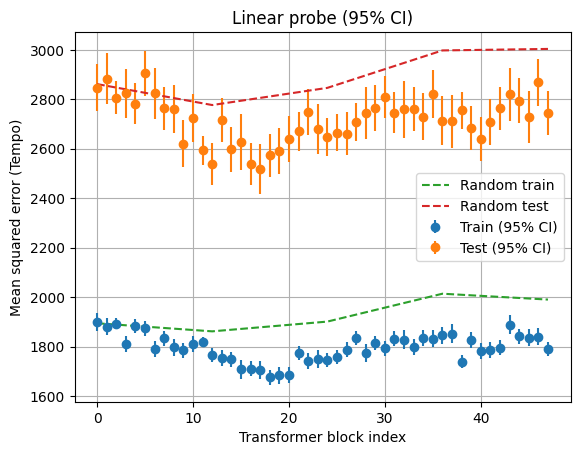

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats

# Organize data by transformer block index
train_data = defaultdict(list)
test_data = defaultdict(list)

for idx, samples in old_records:
    for train, test in samples:
        train_data[idx].append(train)
        test_data[idx].append(test)

# Compute mean and 95% CI for each block
train_means = []
train_cis = []
test_means = []
test_cis = []
indices = sorted(train_data.keys())

for idx in indices:
    train_vals = np.array(train_data[idx])
    test_vals = np.array(test_data[idx])
    
    n_train = len(train_vals)
    n_test = len(test_vals)
    
    # Mean
    train_mean = np.mean(train_vals)
    test_mean = np.mean(test_vals)
    
    # 95% CI using t-distribution
    train_ci = stats.t.ppf(0.975, n_train-1) * np.std(train_vals, ddof=1) / np.sqrt(n_train)
    test_ci = stats.t.ppf(0.975, n_test-1) * np.std(test_vals, ddof=1) / np.sqrt(n_test)
    
    train_means.append(train_mean)
    train_cis.append(train_ci)
    test_means.append(test_mean)
    test_cis.append(test_ci)

    # print(f"layer {idx:02d} | train: {train_mean*100:.2f}%, train: {test_mean*100:.2f}%")

logger.setLevel("INFO")

# Plot with 95% CI error bars
plt.gca().clear()
plt.errorbar(indices, train_means, yerr=train_cis, fmt='o', label="Train (95% CI)")
plt.errorbar(indices, test_means, yerr=test_cis, fmt='o', label="Test (95% CI)")
plt.xlabel("Transformer block index")
plt.ylabel("Mean squared error (Tempo)")
plt.title("Linear probe (95% CI)")

plt.plot([0, 12, 24, 36, 47], random_train_test[:,0], linestyle="--", label="Random train")
plt.plot([0, 12, 24, 36, 47], random_train_test[:,1], linestyle="--", label="Random test")

plt.legend()

plt.grid()
plt.show()